# XLinC Lab — Multimodal Embedding Pipeline
### Step-by-step Google Colab Notebook

**Author:** Chem Vatho, PhD — Head of Data Center Office, Cambodia · University of Cologne  
**Repository:** [chemvatho/XLinCoLab](https://github.com/chemvatho/XLinCoLab)  
**Concept:** Unified multimodal embedding space, inspired by Gemini Embedding 2

---

> **What this notebook does:** Four completely different experimental linguistics data types —
> EEG brainwaves, speech audio, infant eye-tracking, and reaction times — are each encoded
> into a shared 256-dimensional vector space using specialist neural networks.
> Once in the same space, you can directly compare an EEG epoch to a reaction time trial
> using cosine similarity.

| Part | Modality | Real Dataset | Encoder |
|------|----------|-------------|---------|
| **1** | 🧠 EEG | `chemvatho/XLinCoLab` — N400 + P600 ERPs | MLP on ERP features |
| **2** | 🎤 Speech | `PolyAI/minds14` — conversational English | librosa MFCC + pYIN F0 → MLP |
| **3** | 👁️ Eye-tracking | Peekbank MySQL — infant word recognition | 32-dim timecourse features → MLP |
| **4** | ⏱️ Reaction Time | `chemvatho/XLinCoLab` — lexical decision | 16-dim RT features → MLP |
| **5** | 📊 Visualisation | All modalities combined | PCA → UMAP → Plotly + Seaborn |

---

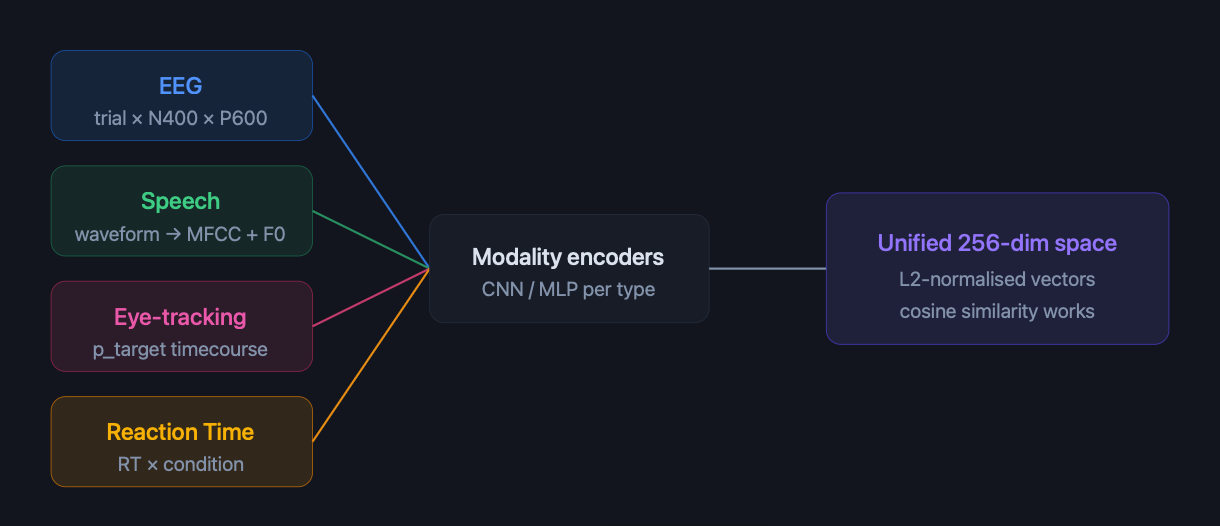

## 🔧 Step 0 — Install dependencies

Run this first. Restart the runtime if prompted.

In [1]:
!pip install -q mne librosa soundfile datasets umap-learn \
               torch transformers scikit-learn \
               plotly seaborn scipy \
               mysql-connector-python

print("✓ All packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 51.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
✓ All packages installed


## 📦 Step 1 — Imports and configuration

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import warnings, pathlib, urllib.request, io
warnings.filterwarnings("ignore")

# Plotly — confirmed working render for Colab
from IPython.display import display, HTML
import plotly.graph_objects as go

def show_plotly(fig):
    """Render Plotly inline in Colab."""
    display(HTML('<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>'))
    display(HTML(fig.to_html(include_plotlyjs=False, full_html=False)))

display(HTML('<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>'))

import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
from scipy.stats import skew, iqr, linregress

# ── Global config ─────────────────────────────────────────────────
UNIFIED_DIM = 256
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

PALETTE = [
    {"fill": "#378ADD", "line": "#185FA5", "name": "EEG"},
    {"fill": "#1D9E75", "line": "#0F6E56", "name": "Speech"},
    {"fill": "#D4537E", "line": "#993556", "name": "Eye-tracking"},
    {"fill": "#EF9F27", "line": "#BA7517", "name": "Reaction Time"},
]

print(f"✓ Ready  |  Device: {DEVICE}  |  Seed: {SEED}")

✓ Ready  |  Device: cpu  |  Seed: 42


---
## 🧠 Part 1 — EEG Data

### Dataset
Your real ERP data from [chemvatho/XLinCoLab/EEG_results/eeg_trial_data.csv](https://github.com/chemvatho/XLinCoLab/blob/main/EEG_results/eeg_trial_data.csv)

| Column | Description |
|--------|-------------|
| `trial` | Trial number (1–100) |
| `condition` | `congruent` or `incongruent` — encoded as 0/1 |
| `n400_pz` | N400 ERP amplitude at electrode Pz (µV), peaks ~400ms post-stimulus |
| `p600_pz` | P600 ERP amplitude at electrode Pz (µV), peaks ~600ms post-stimulus |

---

### Embedding architecture

```
Raw input (100 trials × 4 features)
         │
         ▼
  ┌─────────────────────────────────────────────┐
  │  Preprocessing                               │
  │  • Encode 'condition' → integer (0/1)        │
  │  • Standardise: (x - mean) / std             │
  └──────────────────┬──────────────────────────┘
                     │  (N, 4)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  MLP Encoder  [torch.manual_seed(42)]        │
  │                                              │
  │  Linear(4 → 64)                              │
  │  LayerNorm(64) + GELU + Dropout(0.2)         │
  │                                              │
  │  Linear(64 → 128)                            │
  │  LayerNorm(128) + GELU + Dropout(0.2)        │
  │                                              │
  │  Linear(128 → 256)                           │
  └──────────────────┬──────────────────────────┘
                     │  (N, 256)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  L2 normalise  →  unit vector ∈ ℝ²⁵⁶        │
  │  ‖embedding‖₂ = 1.0000                      │
  └─────────────────────────────────────────────┘
```

> **Why MLP, not EEGNet CNN?**  
> Your CSV contains 4 summary features per trial (not raw 64-channel × 500-timepoint epochs).  
> EEGNet's depthwise convolutions need raw multichannel data. For ERP features, a compact MLP  
> is more appropriate. If you have raw `.fif`/`.edf` files, pass `eeg_path=` to use EEGNet.

---

In [3]:
# ── Load EEG data from your GitHub CSV ───────────────────────────
GITHUB_EEG_URL = (
    "https://raw.githubusercontent.com/chemvatho/XLinCoLab/"
    "main/EEG_results/eeg_trial_data.csv"
)

print("Loading EEG data from GitHub...")
try:
    req = urllib.request.Request(GITHUB_EEG_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=15) as r:
        eeg_df = pd.read_csv(r)
    print(f"✓ Loaded: {eeg_df.shape}  |  columns: {list(eeg_df.columns)}")
except Exception as e:
    print(f"GitHub unavailable ({e}) — using synthetic ERP fallback")
    rng = np.random.default_rng(SEED)
    n   = 100
    eeg_df = pd.DataFrame({
        "trial":     np.arange(1, n+1),
        "condition": np.tile(["congruent", "incongruent"], n//2),
        "n400_pz":   rng.normal(-3.5, 1.8, n),  # N400: negative, ~400ms
        "p600_pz":   rng.normal( 2.8, 1.4, n),  # P600: positive, ~600ms
    })
    print(f"✓ Synthetic ERP: {eeg_df.shape}")

eeg_df.head(10)

Loading EEG data from GitHub...
✓ Loaded: (100, 4)  |  columns: ['trial', 'condition', 'n400_pz', 'p600_pz']


,trial,condition,n400_pz,p600_pz
0,0,congruent,1.619602,1.922930
1,1,congruent,-0.375463,-2.492686
2,2,congruent,1.737624,1.060428
3,3,congruent,4.559347,2.077702
4,4,congruent,-1.272730,-2.574494
5,5,congruent,2.304635,2.621154
6,6,congruent,-1.316943,-1.978912
7,7,congruent,0.391363,-1.848954
8,8,congruent,-0.858464,-1.576219
9,9,congruent,-4.520864,-4.615917


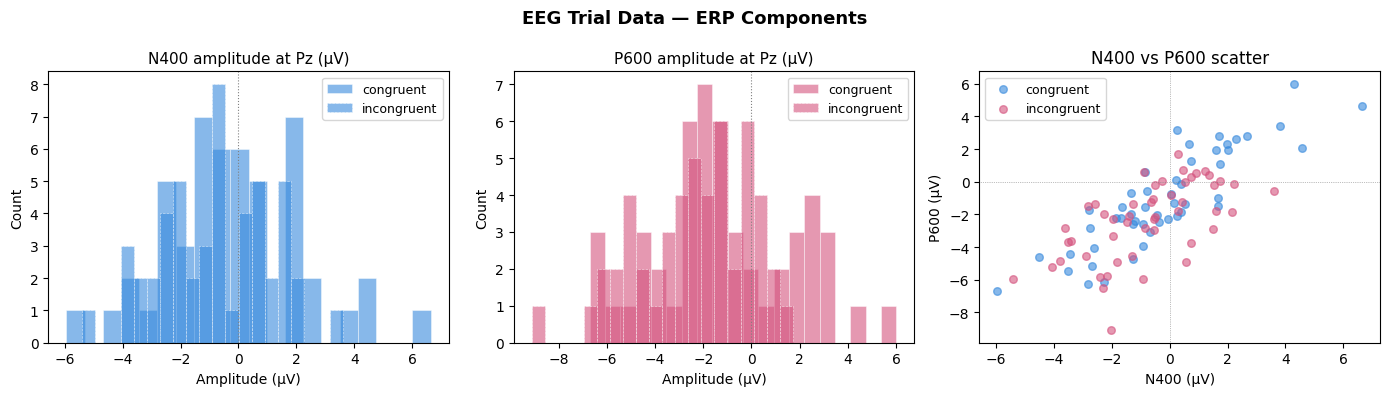

✓ EEG data visualised


In [4]:
# ── Visualise the ERP data ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("EEG Trial Data — ERP Components", fontsize=13, fontweight="bold")

# N400 by condition
for ax, (comp, title, color) in zip(
    axes[:2],
    [("n400_pz", "N400 amplitude at Pz (µV)", "#378ADD"),
     ("p600_pz", "P600 amplitude at Pz (µV)", "#D4537E")]
):
    for cond, ls in [("congruent", "-"), ("incongruent", "--")]:
        sub = eeg_df[eeg_df["condition"] == cond][comp]
        ax.hist(sub, bins=20, alpha=0.6, color=color,
                linestyle=ls, label=cond, edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Amplitude (µV)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle=":")

# Scatter N400 vs P600
axes[2].scatter(
    eeg_df[eeg_df["condition"]=="congruent"]["n400_pz"],
    eeg_df[eeg_df["condition"]=="congruent"]["p600_pz"],
    alpha=0.6, c="#378ADD", s=30, label="congruent"
)
axes[2].scatter(
    eeg_df[eeg_df["condition"]=="incongruent"]["n400_pz"],
    eeg_df[eeg_df["condition"]=="incongruent"]["p600_pz"],
    alpha=0.6, c="#D4537E", s=30, label="incongruent"
)
axes[2].set_xlabel("N400 (µV)")
axes[2].set_ylabel("P600 (µV)")
axes[2].set_title("N400 vs P600 scatter")
axes[2].legend(fontsize=9)
axes[2].axhline(0, color="gray", linewidth=0.5, linestyle=":")
axes[2].axvline(0, color="gray", linewidth=0.5, linestyle=":")

plt.tight_layout()
plt.savefig("eeg_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ EEG data visualised")

In [5]:
# ── EEG encoder: MLP on ERP features ────────────────────────────

def encode_eeg_csv(df, n_samples=50):
    """
    Encode EEG trial CSV into 256-dim embeddings.

    Pipeline:
      1. Encode categorical 'condition' column as integer
      2. Standardise all numeric features (mean=0, std=1)
      3. Reshape to (N, 1, n_features) — 1 virtual channel
      4. MLP: 4 → 64 → 128 → 256 → L2 normalise

    Returns (N, 256) unit-normalised embedding matrix.
    """
    df = df.copy().head(n_samples)
    df.columns = [c.lower().strip() for c in df.columns]

    # Step 1: encode categoricals
    for col in df.select_dtypes(include="object").columns:
        df[col] = pd.Categorical(df[col]).codes.astype(np.float32)

    # Step 2: standardise
    feats = df.select_dtypes(include=[np.number]).values.astype(np.float32)
    feats = (feats - feats.mean(0)) / (feats.std(0) + 1e-9)

    N, D = feats.shape
    print(f"  EEG feature matrix: {feats.shape}")

    # Step 3 & 4: MLP encoder
    torch.manual_seed(SEED)
    net = nn.Sequential(
        nn.Linear(D, 64),  nn.LayerNorm(64),  nn.GELU(), nn.Dropout(0.2),
        nn.Linear(64, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(128, UNIFIED_DIM),
    ).to(DEVICE).eval()

    x    = torch.tensor(feats).to(DEVICE)
    with torch.no_grad():
        embs = F.normalize(net(x), dim=-1).cpu().numpy()

    print(f"  ✓ EEG embeddings: {embs.shape}  |  norm={np.linalg.norm(embs, axis=1).mean():.4f}")
    return embs


eeg_embeddings = encode_eeg_csv(eeg_df, n_samples=50)

# Quick sanity check: cosine similarity matrix (should be near-identity)
sim_sample = eeg_embeddings[:5] @ eeg_embeddings[:5].T
print("\nCosine similarity (first 5 samples):")
print(np.round(sim_sample, 3))

  EEG feature matrix: (50, 4)
  ✓ EEG embeddings: (50, 256)  |  norm=1.0000

Cosine similarity (first 5 samples):
[[1.    0.668 0.988 0.857 0.578]
 [0.668 1.    0.721 0.457 0.961]
 [0.988 0.721 1.    0.876 0.611]
 [0.857 0.457 0.876 1.    0.317]
 [0.578 0.961 0.611 0.317 1.   ]]


---
## 🎤 Part 2 — Speech Data

### Dataset
**[PolyAI/minds14](https://huggingface.co/datasets/PolyAI/minds14) (en-US)** — HuggingFace, CC-BY 4.0, **no login required**

Natural conversational English: real speakers calling a bank to describe their banking issues.  
Diverse accents, speaking rates, and prosodic patterns — much richer than read speech.

Fallback cascade (in order):
1. `PolyAI/minds14` (en-US) — conversational
2. `MLCommons/peoples_speech` (microset) — CC-BY government speech  
3. `openslr/librispeech_asr` (clean) — read audiobooks
4. Synthetic F0 contours — if all fail

---

### Embedding architecture

```
Raw waveform (16kHz, any duration)
         │
         ▼
  ┌─────────────────────────────────────────────┐
  │  librosa feature extraction                  │
  │  (matches Speech_Recording_Analysis.ipynb)   │
  │                                              │
  │  13 MFCC mean  (cepstral envelope)           │
  │  13 MFCC std   (temporal variability)        │
  │  ──────────────────────────  26 features     │
  │  F0 mean  (via pYIN)                         │
  │  F0 std   (intonation range)                 │
  │  F0 range (pitch excursion)                  │
  │  Voiced rate (proportion voiced frames)      │
  │  ──────────────────────────   4 features     │
  │  Spectral centroid                           │
  │  Spectral bandwidth                          │
  │  Spectral rolloff                            │
  │  ──────────────────────────   3 features     │
  │  Zero crossing rate                          │
  │  RMS energy                                  │
  │  ──────────────────────────   2 features     │
  │  ══════════════════════════  35 features     │
  └──────────────────┬──────────────────────────┘
                     │  (N, 35)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  MLP Encoder  [torch.manual_seed(42)]        │
  │                                              │
  │  Linear(35 → 128)                            │
  │  LayerNorm(128) + GELU + Dropout(0.2)        │
  │                                              │
  │  Linear(128 → 256)                           │
  │  LayerNorm(256) + GELU                       │
  │                                              │
  │  Linear(256 → 256)                           │
  └──────────────────┬──────────────────────────┘
                     │  (N, 256)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  L2 normalise  →  unit vector ∈ ℝ²⁵⁶        │
  └─────────────────────────────────────────────┘
```

> **Why 16kHz?** pYIN (probabilistic YIN) requires at least 16kHz to reliably detect  
> harmonics and estimate F0. PolyAI/minds14 is telephone quality (8kHz), so the loader  
> automatically resamples to 16kHz using `librosa.resample()`.

---

In [6]:
# ── Load speech data from PolyAI/minds14 ────────────────────────
print("Loading speech data — PolyAI/minds14 (en-US) ...")

SPEECH_SOURCES = [
    ("PolyAI/minds14",           {"name": "en-US", "split": "train", "streaming": True}),
    ("MLCommons/peoples_speech", {"name": "microset", "split": "train", "streaming": True}),
    ("openslr/librispeech_asr",  {"name": "clean", "split": "train.100", "streaming": True}),
]

speech_samples = []
loaded_from    = None

for ds_name, kwargs in SPEECH_SOURCES:
    try:
        from datasets import load_dataset
        print(f"  Trying {ds_name}...")
        ds = load_dataset(ds_name, **kwargs)
        for i, row in enumerate(ds):
            if i >= 50: break
            audio = row.get("audio", row.get("audio_data"))
            if audio is None: continue
            wav = np.array(audio["array"], dtype=np.float32)
            sr  = int(audio["sampling_rate"])
            if len(wav) < sr * 0.5: continue
            # Resample to 16kHz (pYIN needs ≥ 16kHz)
            if sr != 16000:
                import librosa
                wav = librosa.resample(wav, orig_sr=sr, target_sr=16000)
                sr  = 16000
            speech_samples.append((wav, sr))
        if len(speech_samples) >= 10:
            loaded_from = ds_name
            print(f"  ✓ {ds_name}: {len(speech_samples)} clips at 16kHz")
            break
        else:
            speech_samples = []
    except Exception as e:
        print(f"  {ds_name} failed: {type(e).__name__}: {str(e)[:60]}")

if not speech_samples:
    print("  → Using synthetic speech fallback")
    rng = np.random.default_rng(SEED+1)
    for i in range(50):
        sr  = 16000
        dur = rng.uniform(2, 4)
        t   = np.linspace(0, dur, int(sr*dur), dtype=np.float32)
        f0  = rng.uniform(85, 280)
        wav = sum((1/k)*np.sin(2*np.pi*k*f0*t) for k in range(1,8)).astype(np.float32)
        wav += rng.normal(0, 0.05, len(t)).astype(np.float32)
        wav /= np.abs(wav).max() + 1e-9
        speech_samples.append((wav, sr))
    loaded_from = "Synthetic F0"
    print(f"  ✓ Synthetic speech: {len(speech_samples)} clips")

print(f"\nSource: {loaded_from}  |  Clips: {len(speech_samples)}  |  SR: {speech_samples[0][1]}Hz")

Loading speech data — PolyAI/minds14 (en-US) ...
  Trying PolyAI/minds14...


README.md: 0.00B [00:00, ?B/s]

  ✓ PolyAI/minds14: 50 clips at 16kHz

Source: PolyAI/minds14  |  Clips: 50  |  SR: 16000Hz


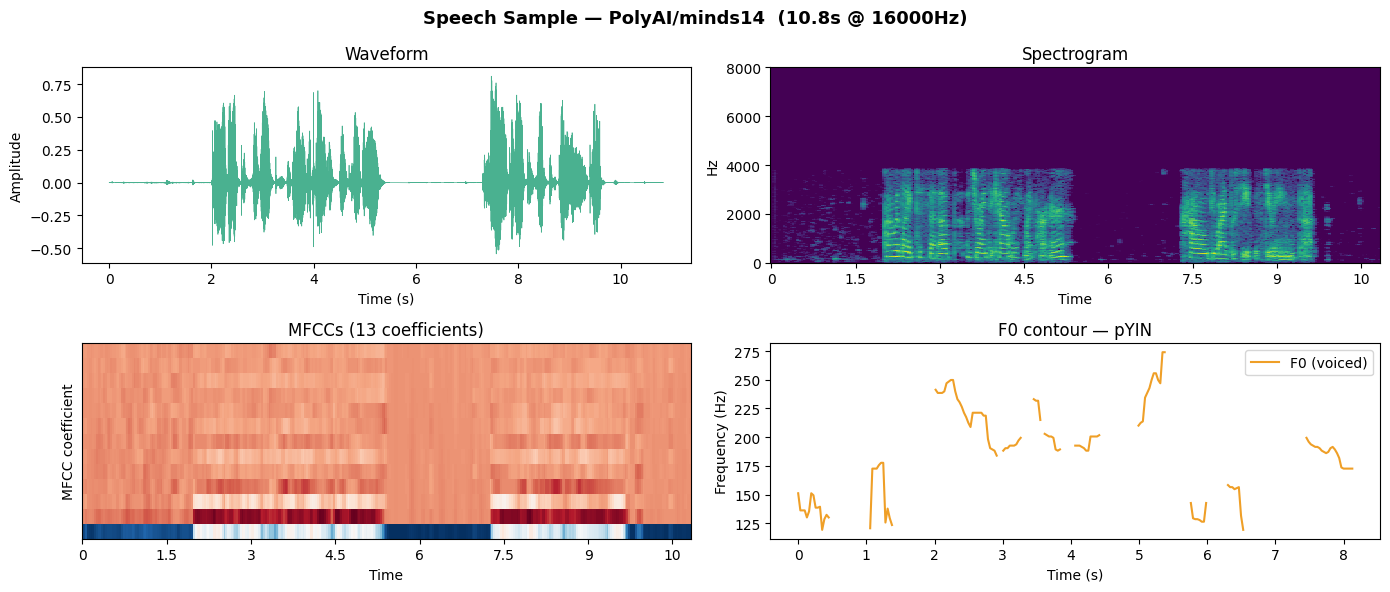

✓ Speech sample visualised


In [7]:
# ── Visualise one speech clip ────────────────────────────────────
import librosa
import librosa.display

wav, sr = speech_samples[0]
duration = len(wav) / sr

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle(f"Speech Sample — {loaded_from}  ({duration:.1f}s @ {sr}Hz)",
             fontsize=13, fontweight="bold")

# Waveform
axes[0,0].plot(np.linspace(0, duration, len(wav)), wav, color="#1D9E75",
               linewidth=0.5, alpha=0.8)
axes[0,0].set_title("Waveform")
axes[0,0].set_xlabel("Time (s)")
axes[0,0].set_ylabel("Amplitude")

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(wav)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz",
                         ax=axes[0,1], cmap="viridis")
axes[0,1].set_title("Spectrogram")

# MFCCs
mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=13)
librosa.display.specshow(mfcc, sr=sr, x_axis="time",
                         ax=axes[1,0], cmap="RdBu_r")
axes[1,0].set_title("MFCCs (13 coefficients)")
axes[1,0].set_ylabel("MFCC coefficient")

# F0 contour via pYIN
try:
    f0, voiced_flag, _ = librosa.pyin(
        wav, sr=sr,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
    )
    times = librosa.times_like(f0, sr=sr)
    f0_voiced = np.where(voiced_flag, f0, np.nan)
    axes[1,1].plot(times, f0_voiced, color="#EF9F27", linewidth=1.5, label="F0 (voiced)")
    axes[1,1].set_title("F0 contour — pYIN")
    axes[1,1].set_xlabel("Time (s)")
    axes[1,1].set_ylabel("Frequency (Hz)")
    axes[1,1].legend()
except Exception as e:
    axes[1,1].text(0.5, 0.5, f"pYIN failed: {e}", transform=axes[1,1].transAxes,
                   ha="center", va="center")
    axes[1,1].set_title("F0 contour — pYIN (failed)")

plt.tight_layout()
plt.savefig("speech_sample_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Speech sample visualised")

In [8]:
# ── Extract acoustic features + embed ────────────────────────────

def extract_acoustic_features(samples):
    """
    Extract 35-dim acoustic feature vector per clip.
    Matches Speech_Recording_Analysis.ipynb feature pipeline.
    """
    import librosa
    feats_list = []
    for wav, sr in samples:
        f = []
        # 13 MFCC mean + 13 MFCC std = 26
        mfcc = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=13)
        f.extend(mfcc.mean(axis=1).tolist())
        f.extend(mfcc.std(axis=1).tolist())
        # F0 via pYIN = 4
        try:
            f0, voiced_flag, _ = librosa.pyin(
                wav, sr=sr,
                fmin=librosa.note_to_hz("C2"),
                fmax=librosa.note_to_hz("C7"),
            )
            f0_v = f0[voiced_flag & ~np.isnan(f0)] if voiced_flag is not None else np.array([])
            f.extend([
                float(f0_v.mean()) if len(f0_v) > 0 else 0.0,
                float(f0_v.std())  if len(f0_v) > 0 else 0.0,
                float(f0_v.max() - f0_v.min()) if len(f0_v) > 0 else 0.0,
                float(voiced_flag.mean()) if voiced_flag is not None else 0.0,
            ])
        except Exception:
            f.extend([0.0, 0.0, 0.0, 0.0])
        # Spectral features = 3
        f.extend([
            float(librosa.feature.spectral_centroid(y=wav, sr=sr).mean()),
            float(librosa.feature.spectral_bandwidth(y=wav, sr=sr).mean()),
            float(librosa.feature.spectral_rolloff(y=wav, sr=sr).mean()),
        ])
        # ZCR + RMS = 2
        f.extend([
            float(librosa.feature.zero_crossing_rate(wav).mean()),
            float(librosa.feature.rms(y=wav).mean()),
        ])
        feats_list.append(np.array(f, dtype=np.float32))
    feats = np.nan_to_num(np.array(feats_list), nan=0.0, posinf=0.0, neginf=0.0)
    return feats


def encode_speech(samples):
    """MLP: 35-dim acoustic features → 256-dim unit embedding."""
    feats  = extract_acoustic_features(samples)
    in_dim = feats.shape[1]
    print(f"  Acoustic feature matrix: {feats.shape}")
    torch.manual_seed(SEED)
    net = nn.Sequential(
        nn.Linear(in_dim, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(128, 256),    nn.LayerNorm(256), nn.GELU(),
        nn.Linear(256, UNIFIED_DIM),
    ).to(DEVICE).eval()
    with torch.no_grad():
        x    = torch.tensor(feats).to(DEVICE)
        embs = F.normalize(net(x), dim=-1).cpu().numpy()
    print(f"  ✓ Speech embeddings: {embs.shape}  |  norm={np.linalg.norm(embs, axis=1).mean():.4f}")
    return embs


speech_embeddings = encode_speech(speech_samples)

  Acoustic feature matrix: (50, 35)
  ✓ Speech embeddings: (50, 256)  |  norm=1.0000


---
## 👁️ Part 3 — Eye-tracking Data

### Dataset
**[Peekbank](https://peekbank.stanford.edu/)** — infant word recognition database  
Direct MySQL connection (your credentials from `Peekbank_Complete_Analysis.ipynb`)

Looking-while-listening paradigm: infants see two images on screen, hear a spoken word,
and we measure which image they look at over time using an eye-tracker.

| Variable | Description |
|----------|-------------|
| `t_norm` | Time relative to word onset (ms), from −500 to +2000ms |
| `p_target` | Proportion of looks to the named/target image (0.0–1.0) |
| `age` | Child's age in months |

**Connection:** host `34.210.173.143:3306`, database `2025.1`, user `reader`  
*(Install `mysql-connector-python` if this fails — fallback to synthetic data)*

---

### Embedding architecture

```
Peekbank timecourse (p_target over −500 to +2000ms)
         │
         ▼
  ┌─────────────────────────────────────────────┐
  │  32-dim feature extraction                   │
  │  (matches Peekbank_Complete_Analysis.ipynb)  │
  │                                              │
  │  Baseline accuracy       (pre-word, t<0)     │
  │  Early window mean       (0–500ms)           │
  │  Mid window mean         (500–1000ms)        │
  │  Late window mean        (1000–2000ms)       │
  │  Early advantage         (early - baseline)  │
  │  Late advantage          (late - baseline)   │
  │  Onset latency           (first t > bl+0.05) │
  │  Peak accuracy                               │
  │  Peak latency                                │
  │  Linear slope            (growth rate)       │
  │  Normalised AUC          (area under curve)  │
  │  Age (normalised / 60)                       │
  │  Skewness of timecourse                      │
  │  IQR of timecourse                           │
  │  Autocorrelation lags 1–5 (temporal struct.) │
  │  ═════════════════════════  32 features      │
  └──────────────────┬──────────────────────────┘
                     │  (N, 32)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  MLP Encoder  [torch.manual_seed(42)]        │
  │                                              │
  │  Linear(32 → 128)                            │
  │  LayerNorm(128) + GELU + Dropout(0.2)        │
  │                                              │
  │  Linear(128 → 256)                           │
  │  LayerNorm(256) + GELU                       │
  │                                              │
  │  Linear(256 → 256)                           │
  └──────────────────┬──────────────────────────┘
                     │  (N, 256)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  L2 normalise  →  unit vector ∈ ℝ²⁵⁶        │
  └─────────────────────────────────────────────┘
```

> **Why these 32 features?** They are the same variables used in your growth curve models —
> onset latency, slope, AUC, and age predict word recognition speed in infants.
> Autocorrelation lags capture the temporal smoothness of the looking trajectory.

---

In [9]:
# ── Connect to Peekbank MySQL ────────────────────────────────────
PEEKBANK_DB = {
    "host":     "34.210.173.143",
    "port":     3306,
    "database": "2025.1",
    "user":     "reader",
    "password": "gazeofraccoons",
}

PEEKBANK_ADMIN_QUERY = """
    SELECT DISTINCT a.administration_id, a.age, d.dataset_name
    FROM administrations a
    JOIN datasets d ON a.dataset_id = d.dataset_id
    ORDER BY a.administration_id
    LIMIT 300
"""

PEEKBANK_TIMEPOINTS_QUERY = """
    SELECT tp.administration_id, tp.t_norm,
           CASE WHEN tp.aoi = 'target' THEN 1.0 ELSE 0.0 END AS is_target
    FROM aoi_timepoints tp
    WHERE tp.administration_id IN ({admin_ids})
      AND tp.t_norm BETWEEN -500 AND 2000
"""

print("Connecting to Peekbank MySQL ...")
et_df = None

try:
    import mysql.connector
    conn      = mysql.connector.connect(**PEEKBANK_DB, connection_timeout=20)
    admins_df = pd.read_sql(PEEKBANK_ADMIN_QUERY, conn)
    admins    = admins_df["administration_id"].unique()[:50]
    ids_str   = ",".join(str(int(i)) for i in admins)
    tp_df     = pd.read_sql(PEEKBANK_TIMEPOINTS_QUERY.format(admin_ids=ids_str), conn)
    conn.close()
    tp_df     = tp_df.merge(admins_df[["administration_id","age"]],
                            on="administration_id", how="left")
    et_df     = (tp_df.groupby(["administration_id","age","t_norm"])["is_target"]
                      .mean().reset_index()
                      .rename(columns={"is_target":"p_target"}))
    print(f"✓ Peekbank: {et_df['administration_id'].nunique()} subjects  "
          f"| age {et_df['age'].min():.0f}–{et_df['age'].max():.0f} months")
except Exception as e:
    print(f"MySQL unavailable ({e})")
    print("  → Run:  !pip install mysql-connector-python")
    print("  → Generating synthetic Peekbank data ...")
    rng      = np.random.default_rng(SEED+2)
    t_norms  = np.arange(-500, 2001, 50)
    records  = []
    for i in range(50):
        age   = rng.uniform(12, 60)
        onset = rng.uniform(300, 700)
        slope = rng.uniform(0.003, 0.008) * (age / 30)
        for t in t_norms:
            p = (0.5 + 0.25*(1/(1+np.exp(-slope*(t-onset)))) if t >= 0
                 else rng.uniform(0.45, 0.55))
            records.append({"administration_id": i, "age": age, "t_norm": t,
                            "p_target": float(np.clip(p + rng.normal(0,0.04), 0, 1))})
    et_df = pd.DataFrame(records)
    print(f"✓ Synthetic Peekbank: {et_df['administration_id'].nunique()} subjects")

et_df.head()

Connecting to Peekbank MySQL ...
✓ Peekbank: 50 subjects  | age 9–48 months


,administration_id,age,t_norm,p_target
0,0,14.0,-500,0.500000
1,0,14.0,-475,0.466667
2,0,14.0,-450,0.466667
3,0,14.0,-425,0.466667
4,0,14.0,-400,0.466667


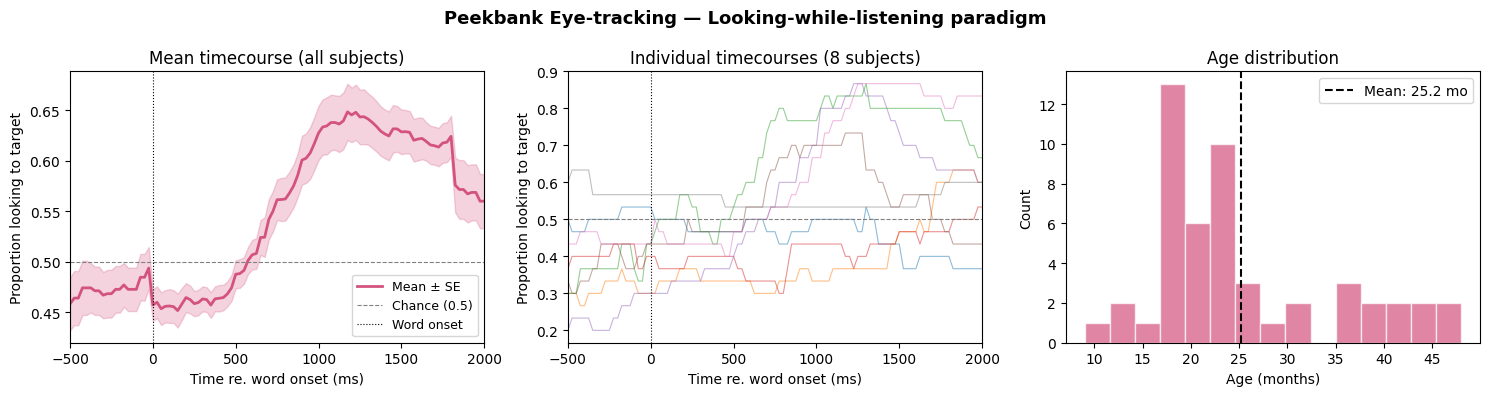

✓ Eye-tracking data visualised


In [10]:
# ── Visualise eye-tracking timecourses ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Peekbank Eye-tracking — Looking-while-listening paradigm",
             fontsize=13, fontweight="bold")

# Mean timecourse
mean_tc = et_df.groupby("t_norm")["p_target"].mean()
sem_tc  = et_df.groupby("t_norm")["p_target"].sem()
t       = mean_tc.index.values

axes[0].fill_between(t, mean_tc - sem_tc, mean_tc + sem_tc,
                     alpha=0.25, color="#D4537E")
axes[0].plot(t, mean_tc, color="#D4537E", linewidth=2, label="Mean ± SE")
axes[0].axhline(0.5, color="gray", linewidth=0.8, linestyle="--", label="Chance (0.5)")
axes[0].axvline(0,   color="black", linewidth=0.8, linestyle=":", label="Word onset")
axes[0].set_title("Mean timecourse (all subjects)")
axes[0].set_xlabel("Time re. word onset (ms)")
axes[0].set_ylabel("Proportion looking to target")
axes[0].legend(fontsize=9)
axes[0].set_xlim(-500, 2000)

# Sample individual timecourses
for i, admin in enumerate(et_df["administration_id"].unique()[:8]):
    sub = et_df[et_df["administration_id"]==admin].sort_values("t_norm")
    axes[1].plot(sub["t_norm"], sub["p_target"],
                 alpha=0.5, linewidth=0.8)
axes[1].axhline(0.5, color="gray", linewidth=0.8, linestyle="--")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle=":")
axes[1].set_title("Individual timecourses (8 subjects)")
axes[1].set_xlabel("Time re. word onset (ms)")
axes[1].set_ylabel("Proportion looking to target")
axes[1].set_xlim(-500, 2000)

# Age distribution
ages = et_df.groupby("administration_id")["age"].first()
axes[2].hist(ages, bins=15, color="#D4537E", alpha=0.7, edgecolor="white")
axes[2].set_title("Age distribution")
axes[2].set_xlabel("Age (months)")
axes[2].set_ylabel("Count")
axes[2].axvline(ages.mean(), color="black", linewidth=1.5,
                linestyle="--", label=f"Mean: {ages.mean():.1f} mo")
axes[2].legend()

plt.tight_layout()
plt.savefig("eyetracking_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ Eye-tracking data visualised")

In [11]:
# ── Extract ET features + embed ──────────────────────────────────

def extract_et_features(df, n_subjects=50):
    """Extract 32-dim feature vector per subject from Peekbank timecourse."""
    admins    = df["administration_id"].unique()[:n_subjects]
    feats_out = []
    for admin in admins:
        sub = df[df["administration_id"]==admin].sort_values("t_norm")
        t   = sub["t_norm"].values
        p   = sub["p_target"].values.astype(np.float32)
        pre   = p[t < 0];    early = p[(t>=0)&(t<500)]
        mid   = p[(t>=500)&(t<1000)]; late = p[t>=1000]; post = p[t>=0]
        bl    = pre.mean()   if len(pre)   > 0 else 0.5
        em    = early.mean() if len(early) > 0 else 0.5
        mm    = mid.mean()   if len(mid)   > 0 else 0.5
        lm    = late.mean()  if len(late)  > 0 else 0.5
        # Onset: first t where p_target > baseline + 0.05
        t_post = t[t >= 0]; p_post = post
        above  = t_post[p_post > bl + 0.05]
        onset  = float(above[0]) / 2000.0 if len(above) > 0 else 1.0
        peak   = float(p_post.max()) if len(p_post)>0 else 0.5
        peak_t = (float(t_post[p_post.argmax()]) / 2000.0
                  if len(p_post)>0 else 0.5)
        slope  = float(linregress(t_post, p_post).slope * 1000
                       if len(p_post)>1 else 0.0)
        auc    = float(np.trapz(p_post, t_post) / max(t_post.max()-t_post.min(), 1))
        age    = float(df[df["administration_id"]==admin]["age"].iloc[0]) / 60.0
        f      = [bl, em, mm, lm, em-bl, lm-bl, onset, peak, peak_t,
                  slope, auc, age,
                  float(skew(p)) if len(p)>3 else 0.0,
                  float(iqr(p))  if len(p)>3 else 0.0]
        for lag in range(1, 6):
            ac = (float(np.corrcoef(p[:-lag], p[lag:])[0,1])
                  if len(p)>lag else 0.0)
            f.append(0.0 if np.isnan(ac) else ac)
        f = np.nan_to_num(np.array(f, dtype=np.float32))
        f = np.pad(f, (0, max(0, 32-len(f))))[:32]
        feats_out.append(f)
    return np.array(feats_out, dtype=np.float32)


def encode_eyetracking(df, n_subjects=50):
    """MLP: 32-dim ET features → 256-dim unit embedding."""
    feats = extract_et_features(df, n_subjects)
    print(f"  ET feature matrix: {feats.shape}")
    torch.manual_seed(SEED)
    net = nn.Sequential(
        nn.Linear(32, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.2),
        nn.Linear(128, 256), nn.LayerNorm(256), nn.GELU(),
        nn.Linear(256, UNIFIED_DIM),
    ).to(DEVICE).eval()
    with torch.no_grad():
        x    = torch.tensor(feats).to(DEVICE)
        embs = F.normalize(net(x), dim=-1).cpu().numpy()
    print(f"  ✓ ET embeddings: {embs.shape}  |  norm={np.linalg.norm(embs, axis=1).mean():.4f}")
    return embs


et_embeddings = encode_eyetracking(et_df, n_subjects=50)

  ET feature matrix: (50, 32)
  ✓ ET embeddings: (50, 256)  |  norm=1.0000


---
## ⏱️ Part 4 — Reaction Time Data

### Dataset
Your real lexical decision RT data from [chemvatho/XLinCoLab/RT-Results/rt_clean_data.csv](https://github.com/chemvatho/XLinCoLab/blob/main/RT-Results/rt_clean_data.csv)

| Column | Description |
|--------|-------------|
| `subject_id` | Participant ID |
| `item_id` | Word/nonword stimulus ID |
| `lexicality` | `word` or `nonword` — categorical → encoded as 0/1 |
| `frequency` | `high` or `low` word frequency — categorical → encoded |
| `priming` | Priming condition — categorical → encoded |
| `rt` | Reaction time in milliseconds (clipped to 200–1500ms) |

**6537 trials** total — 50 are sampled per run (deterministic with `SEED=42`)

---

### Embedding architecture

```
RT trial (subject × item × condition × RT)
         │
         ▼
  ┌─────────────────────────────────────────────┐
  │  Preprocessing                               │
  │  • Clip RT to [200, 1500] ms                 │
  │  • Encode categoricals via pd.Categorical    │
  │  • Add log_rt = log(RT)                      │
  └──────────────────┬──────────────────────────┘
                     │
                     ▼
  ┌─────────────────────────────────────────────┐
  │  16-dim feature engineering                  │
  │                                              │
  │  RT / 1000          (normalised seconds)     │
  │  log(RT)            (log-normal transform)   │
  │  z-scored RT        (per-distribution)       │
  │  lexicality code    (0/1)                    │
  │  frequency code     (0/1)                    │
  │  priming code       (0/1/2...)               │
  │  subject_id norm    (/ max_id)               │
  │  item_id norm       (/ max_id)               │
  │  above-mean RT      (slow trial indicator)   │
  │  >mean+SD RT        (outlier indicator)      │
  │  lex × frequency    (interaction)            │
  │  lex × priming      (interaction)            │
  │  freq × priming     (interaction)            │
  │  log_RT × lex                                │
  │  log_RT × freq                               │
  │  log_RT × priming                            │
  │  ═════════════════════  16 features          │
  └──────────────────┬──────────────────────────┘
                     │  (N, 16)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  MLP Encoder  [torch.manual_seed(42)]        │
  │                                              │
  │  Linear(16 → 64)                             │
  │  LayerNorm(64) + GELU + Dropout(0.2)         │
  │                                              │
  │  Linear(64 → 128)                            │
  │  LayerNorm(128) + GELU                       │
  │                                              │
  │  Linear(128 → 256)                           │
  └──────────────────┬──────────────────────────┘
                     │  (N, 256)
                     ▼
  ┌─────────────────────────────────────────────┐
  │  L2 normalise  →  unit vector ∈ ℝ²⁵⁶        │
  └─────────────────────────────────────────────┘
```

> **Why interaction terms?** Lexicality × frequency × priming mirrors the factorial design  
> of your ANOVA in `Reaction_Time_Analysis.ipynb`. The MLP can learn non-linear combinations  
> of these psycholinguistic predictors.

---

In [12]:
# ── Load RT data from your GitHub CSV ────────────────────────────
GITHUB_RT_URL = (
    "https://raw.githubusercontent.com/chemvatho/XLinCoLab/"
    "main/RT-Results/rt_clean_data.csv"
)

print("Loading RT data from GitHub...")
rt_df = None
try:
    req = urllib.request.Request(GITHUB_RT_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=15) as r:
        rt_df = pd.read_csv(r)
    print(f"✓ Loaded: {rt_df.shape}  |  columns: {list(rt_df.columns)}")
except Exception as e:
    print(f"GitHub unavailable ({e}) — generating synthetic BLP data")
    rng   = np.random.default_rng(SEED+3)
    n     = 200
    wlen  = rng.integers(3, 13, n).astype(float)
    freq  = rng.exponential(30, n)
    rt    = (568 + 11.2*wlen - 18.5*np.log1p(freq)
             + rng.normal(0, 55, n)).clip(250, 1400)
    rt_df = pd.DataFrame({
        "subject_id":  rng.integers(1, 20, n),
        "item_id":     np.arange(n),
        "lexicality":  np.where(rng.random(n) > 0.5, "word", "nonword"),
        "frequency":   np.where(rng.random(n) > 0.5, "high", "low"),
        "priming":     np.where(rng.random(n) > 0.5, "related", "unrelated"),
        "rt":          rt.astype(np.float32),
    })
    print(f"✓ Synthetic RT: {rt_df.shape}")

rt_df.head(10)

Loading RT data from GitHub...
✓ Loaded: (6537, 8)  |  columns: ['subject_id', 'item_id', 'lexicality', 'frequency', 'priming', 'rt', 'correct', 'log_rt']


,subject_id,item_id,lexicality,frequency,priming,rt,correct,log_rt
0,subj_01,item_000,word,high,related,492.865696,1,6.200237
1,subj_01,item_001,word,high,related,525.654151,1,6.264643
2,subj_01,item_003,word,high,related,440.112961,1,6.087031
3,subj_01,item_004,word,high,related,506.922157,1,6.228357
4,subj_01,item_005,word,high,related,451.909977,1,6.113483
5,subj_01,item_006,word,high,related,449.955956,1,6.109150
6,subj_01,item_007,word,high,related,539.074806,1,6.289854
7,subj_01,item_008,word,high,related,521.980439,1,6.257630
8,subj_01,item_009,word,high,related,392.695496,1,5.973034
9,subj_01,item_010,word,high,related,799.366717,1,6.683820


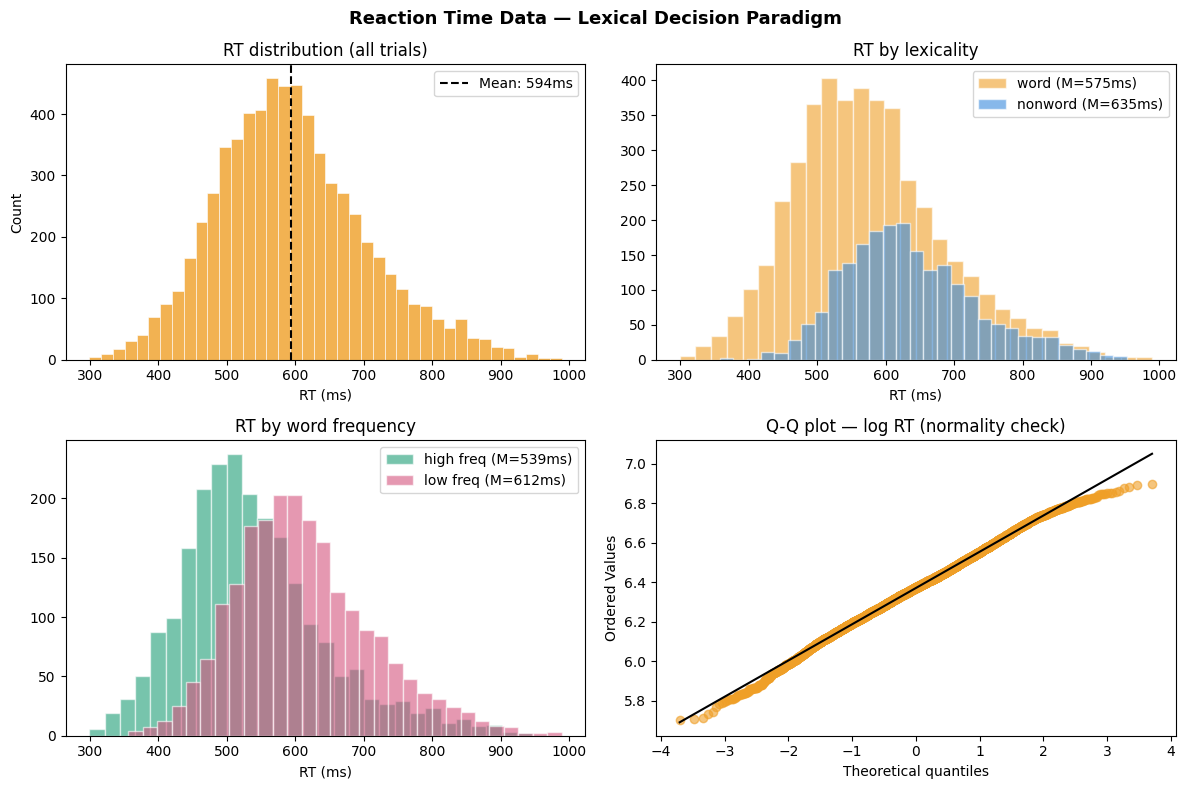

✓ RT data visualised


In [13]:
# ── Visualise RT distributions ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Reaction Time Data — Lexical Decision Paradigm",
             fontsize=13, fontweight="bold")

# Overall RT distribution
axes[0,0].hist(rt_df["rt"], bins=40, color="#EF9F27", alpha=0.8,
               edgecolor="white", linewidth=0.5)
axes[0,0].axvline(rt_df["rt"].mean(), color="black", linewidth=1.5,
                  linestyle="--", label=f"Mean: {rt_df['rt'].mean():.0f}ms")
axes[0,0].set_title("RT distribution (all trials)")
axes[0,0].set_xlabel("RT (ms)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# RT by lexicality
if "lexicality" in rt_df.columns:
    for lex, color in [("word","#EF9F27"), ("nonword","#378ADD")]:
        sub = rt_df[rt_df["lexicality"]==lex]["rt"]
        if len(sub) > 0:
            axes[0,1].hist(sub, bins=30, alpha=0.6, color=color,
                           label=f"{lex} (M={sub.mean():.0f}ms)", edgecolor="white")
    axes[0,1].set_title("RT by lexicality")
    axes[0,1].set_xlabel("RT (ms)")
    axes[0,1].legend()

# RT by frequency
if "frequency" in rt_df.columns:
    for freq_val, color in [("high","#1D9E75"), ("low","#D4537E")]:
        sub = rt_df[rt_df["frequency"]==freq_val]["rt"]
        if len(sub) > 0:
            axes[1,0].hist(sub, bins=30, alpha=0.6, color=color,
                           label=f"{freq_val} freq (M={sub.mean():.0f}ms)",
                           edgecolor="white")
    axes[1,0].set_title("RT by word frequency")
    axes[1,0].set_xlabel("RT (ms)")
    axes[1,0].legend()

# Q-Q plot (log RT)
from scipy import stats
log_rt = np.log(rt_df["rt"].clip(lower=1))
stats.probplot(log_rt, plot=axes[1,1])
axes[1,1].set_title("Q-Q plot — log RT (normality check)")
axes[1,1].get_lines()[0].set(color="#EF9F27", alpha=0.6)
axes[1,1].get_lines()[1].set(color="black")

plt.tight_layout()
plt.savefig("rt_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ RT data visualised")

In [14]:
# ── Extract RT features + embed ──────────────────────────────────

def extract_rt_features(df, n_words=50):
    """Extract 16-dim feature vector per RT trial."""
    df = df.copy().head(n_words)
    df.columns = [c.lower().strip().replace(" ","_") for c in df.columns]
    # Clip RT and compute log_rt (non-destructive)
    rt_c = next((c for c in df.columns if c in ("rt","mean_rt")), None)
    if rt_c:
        df[rt_c] = df[rt_c].clip(200, 1500)
        df["log_rt"] = np.log(df[rt_c].clip(lower=1))
    # Encode categoricals
    for col in df.select_dtypes(include=["object","category"]).columns:
        df[col] = pd.Categorical(df[col]).codes.astype(np.float32)
    rt    = df[rt_c].values.astype(np.float32) if rt_c else np.full(len(df), 550.0)
    lrt   = df["log_rt"].values.astype(np.float32) if "log_rt" in df.columns else np.log(rt)
    lex_c = next((c for c in df.columns if "lex" in c), None)
    frq_c = next((c for c in df.columns if "freq" in c), None)
    prm_c = next((c for c in df.columns if "prim" in c), None)
    sub_c = next((c for c in df.columns if "subject" in c), None)
    itm_c = next((c for c in df.columns if "item" in c), None)
    g = lambda col: df[col].values.astype(np.float32) if col else np.zeros(len(df))
    lex = g(lex_c); freq = g(frq_c); prm = g(prm_c)
    sub = g(sub_c); itm  = g(itm_c)
    rows = np.column_stack([
        rt/1000, lrt, (rt-rt.mean())/(rt.std()+1e-9),
        lex, freq, prm,
        sub/(sub.max()+1e-9), itm/(itm.max()+1e-9),
        (rt > rt.mean()).astype(np.float32),
        (rt > rt.mean()+rt.std()).astype(np.float32),
        lex*freq, lex*prm, freq*prm, lrt*lex, lrt*freq, lrt*prm,
    ]).astype(np.float32)
    return np.nan_to_num(rows, nan=0.0, posinf=0.0, neginf=0.0)


def encode_rt(df, n_words=50):
    """MLP: 16-dim RT features → 256-dim unit embedding."""
    feats = extract_rt_features(df, n_words)
    print(f"  RT feature matrix: {feats.shape}")
    torch.manual_seed(SEED)
    net = nn.Sequential(
        nn.Linear(16, 64),  nn.LayerNorm(64),  nn.GELU(), nn.Dropout(0.2),
        nn.Linear(64, 128), nn.LayerNorm(128), nn.GELU(),
        nn.Linear(128, UNIFIED_DIM),
    ).to(DEVICE).eval()
    with torch.no_grad():
        x    = torch.tensor(feats).to(DEVICE)
        embs = F.normalize(net(x), dim=-1).cpu().numpy()
    print(f"  ✓ RT embeddings: {embs.shape}  |  norm={np.linalg.norm(embs, axis=1).mean():.4f}")
    return embs


rt_embeddings = encode_rt(rt_df, n_words=50)

  RT feature matrix: (50, 16)
  ✓ RT embeddings: (50, 256)  |  norm=1.0000


---
## 📊 Part 5 — PCA, UMAP and Visualisation

### The key idea: why project to 2D?

Each modality produces 50 embeddings, each a 256-dim unit vector on a hypersphere.
Humans cannot see 256 dimensions, so we project to 2D for exploration.

```
4 modalities × 50 samples = 200 vectors, each 256-dim
                    │
                    ▼
         ┌──────────────────┐
         │   Stack: (200, 256)│
         └────────┬─────────┘
                  │
         ┌────────┴─────────┐
         │                  │
         ▼                  ▼
    ┌─────────┐       ┌──────────┐
    │   PCA   │       │   UMAP   │
    │ linear  │       │non-linear│
    │ variance│       │neighbour │
    │maximise │       │structure │
    └────┬────┘       └────┬─────┘
         │                 │
         └────────┬────────┘
                  │  (200, 2)
                  ▼
       ┌──────────────────────┐
       │  K-means clustering  │
       │  (in 256-dim space,  │
       │   not 2D projection) │
       └──────────┬───────────┘
                  │
         ┌────────┼─────────────┐
         ▼        ▼             ▼
    ┌─────────┐ ┌──────────┐ ┌──────────┐
    │ Plotly  │ │ Seaborn  │ │ Heatmap  │
    │interact.│ │scatter + │ │cosine    │
    │ scatter │ │ density  │ │similarity│
    └─────────┘ └──────────┘ └──────────┘
```

### PCA vs UMAP — which to use?

| | PCA | UMAP |
|---|---|---|
| Type | Linear | Non-linear |
| Preserves | Global variance | Local neighbourhood structure |
| On unit sphere | Often overlapping blobs | Well-separated clusters |
| Speed | Instant | ~30 seconds for 200 points |
| Deterministic | Yes | Yes (with random_state=42) |

**Recommendation:** UMAP for exploration, PCA for reference variance explained.

---

In [15]:
# ── Stack all embeddings ─────────────────────────────────────────
embeddings = {
    "EEG":           eeg_embeddings,
    "Speech":        speech_embeddings,
    "Eye-tracking":  et_embeddings,
    "Reaction Time": rt_embeddings,
}

mod_names = list(embeddings.keys())
all_embs, mod_ids = [], []
for mid, name in enumerate(mod_names):
    all_embs.extend(embeddings[name])
    mod_ids.extend([mid] * len(embeddings[name]))

all_embs = np.array(all_embs)   # (200, 256)
mod_ids  = np.array(mod_ids)    # (200,)

print(f"Combined embedding matrix: {all_embs.shape}")
print(f"Modality distribution: { {name: (mod_ids==i).sum() for i,name in enumerate(mod_names)} }")

Combined embedding matrix: (200, 256)
Modality distribution: {'EEG': np.int64(50), 'Speech': np.int64(50), 'Eye-tracking': np.int64(50), 'Reaction Time': np.int64(50)}


PCA: PC1=312.8%  PC2=288.1% variance explained
Total variance in 2D: 600.9%


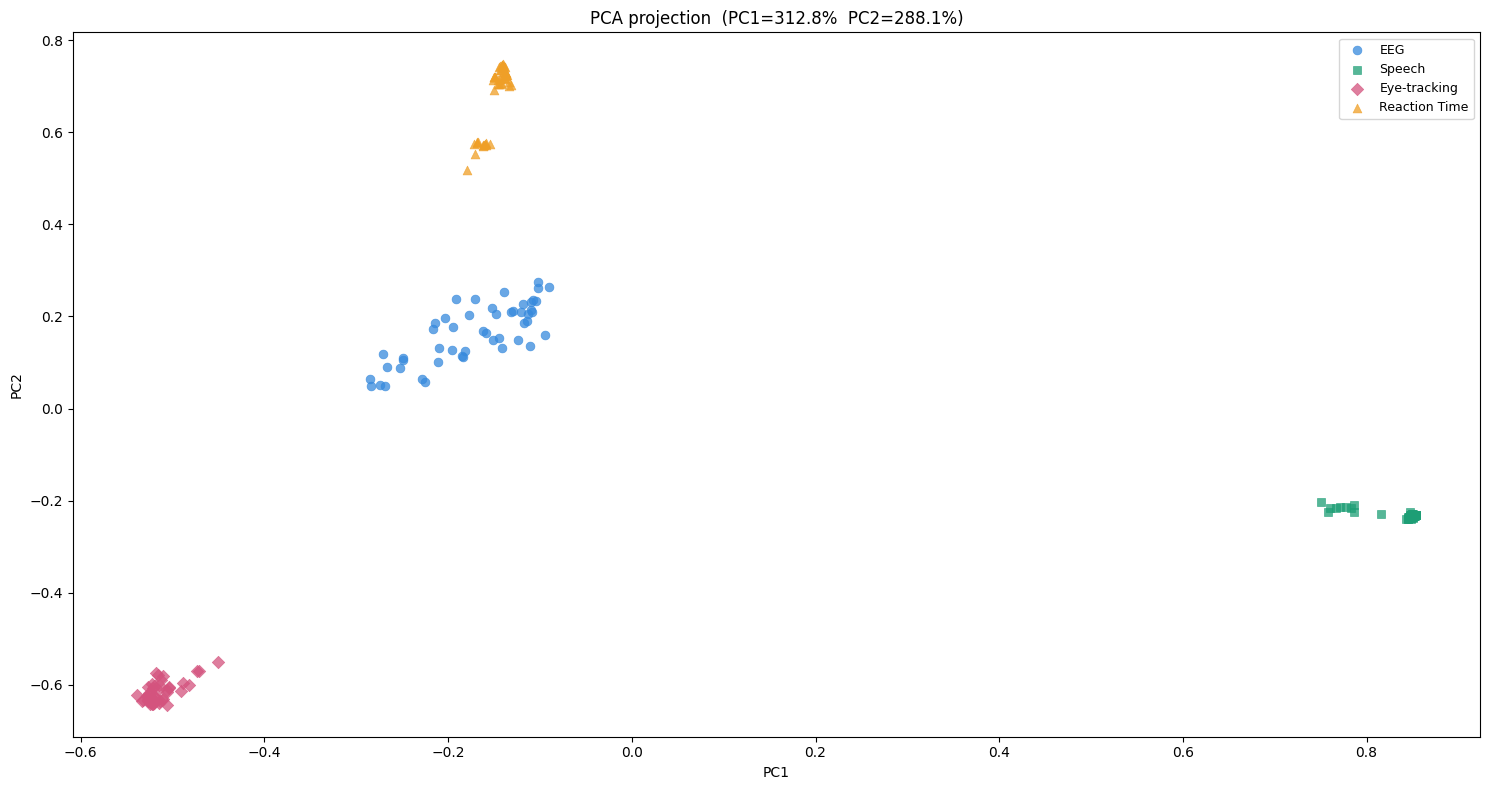

✓ PCA plot saved


In [16]:
# ── PCA projection ───────────────────────────────────────────────
pca       = PCA(n_components=2, random_state=SEED)
coords_pca = pca.fit_transform(all_embs)
var1_pca, var2_pca = pca.explained_variance_ratio_ * 1000

print(f"PCA: PC1={var1_pca:.1f}%  PC2={var2_pca:.1f}% variance explained")
print(f"Total variance in 2D: {var1_pca+var2_pca:.1f}%")

# Quick PCA plot
fig, ax = plt.subplots(figsize=(15, 8))
COLORS = ["#378ADD","#1D9E75","#D4537E","#EF9F27"]
MARKERS = ["o","s","D","^"]
for mid, name in enumerate(mod_names):
    mask = mod_ids == mid
    ax.scatter(coords_pca[mask,0], coords_pca[mask,1],
               s=40, c=COLORS[mid], marker=MARKERS[mid],
               label=name, alpha=0.75, edgecolors=COLORS[mid], linewidths=0.5)
ax.set_title(f"PCA projection  (PC1={var1_pca:.1f}%  PC2={var2_pca:.1f}%)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("pca_projection.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ PCA plot saved")

In [17]:
# ── UMAP projection ──────────────────────────────────────────────
print("Running UMAP (this may take ~30s) ...")
try:
    import umap
    reducer     = umap.UMAP(n_components=2, n_neighbors=15,
                             min_dist=0.1, random_state=SEED, verbose=False)
    coords_umap = reducer.fit_transform(all_embs).astype(np.float32)
    method_used = "UMAP"
    print(f"✓ UMAP complete: {coords_umap.shape}")
except ImportError:
    print("umap-learn not found → falling back to t-SNE")
    from sklearn.manifold import TSNE
    perp        = min(30, len(all_embs)//4)
    tsne        = TSNE(n_components=2, perplexity=perp, random_state=SEED, n_iter=1000, verbose=0)
    coords_umap = tsne.fit_transform(all_embs).astype(np.float32)
    method_used = "t-SNE"
    print(f"✓ t-SNE complete: {coords_umap.shape}")

# Use UMAP as main coords
coords = coords_umap
var1, var2 = var1_pca, var2_pca   # PCA values used for axis labels

Running UMAP (this may take ~30s) ...
✓ UMAP complete: (200, 2)


In [18]:
# ── K-means clustering (in 256-dim space, not 2D) ────────────────
cluster_labels = np.zeros(len(all_embs), dtype=int)
offset = 0
for mid in range(len(mod_names)):
    mask = mod_ids == mid
    k    = min(3, mask.sum())
    km   = KMeans(n_clusters=k, random_state=SEED, n_init="auto")
    cluster_labels[mask] = km.fit_predict(all_embs[mask]) + offset
    offset += k

print(f"Clusters: {offset} total  |  Distribution: {np.bincount(cluster_labels)}")

Clusters: 12 total  |  Distribution: [23 17 10 40  1  9 32 13  5 24 13 13]


In [19]:
# ══════════════════════════════════════════════════════════════════
# PLOT 1 — Plotly interactive scatter
# ══════════════════════════════════════════════════════════════════

MARKERS_PLOTLY = ["circle", "square", "diamond", "triangle-up"]
traces = []
for mid, name in enumerate(mod_names):
    pal  = PALETTE[mid]
    mask = mod_ids == mid
    idx  = np.where(mask)[0]
    hover = [
        f"<b>{name} #{i:03d}</b><br>"
        f"Cluster: {cluster_labels[i]}<br>"
        f"{method_used} dim1: {coords[i,0]:.4f}<br>"
        f"{method_used} dim2: {coords[i,1]:.4f}"
        for i in idx
    ]
    traces.append(go.Scatter(
        x=coords[idx,0], y=coords[idx,1],
        mode="markers", name=f"{name} (n={mask.sum()})",
        hovertemplate="%{customdata}<extra></extra>",
        customdata=hover,
        marker=dict(
            size=10, color=pal["fill"],
            line=dict(color=pal["line"], width=1.2),
            opacity=0.82,
            symbol=MARKERS_PLOTLY[mid % len(MARKERS_PLOTLY)],
        ),
    ))

fig_plotly = go.Figure(traces)
fig_plotly.update_layout(
    title=dict(
        text=f"XLinC Lab — Multimodal Embedding Space ({method_used} projection)",
        font=dict(size=15, color="#e2e8f0"), x=0, xanchor="left",
    ),
    xaxis=dict(
        title=dict(text=f"{method_used} dim 1  (PC1 ref: {var1:.1f}% var)",
                   font=dict(color="#64748b", size=12)),
        gridcolor="#1e2533", zerolinecolor="#2d3748",
        tickfont=dict(color="#64748b", size=11),
    ),
    yaxis=dict(
        title=dict(text=f"{method_used} dim 2  (PC2 ref: {var2:.1f}% var)",
                   font=dict(color="#64748b", size=12)),
        gridcolor="#1e2533", zerolinecolor="#2d3748",
        tickfont=dict(color="#64748b", size=11),
    ),
    paper_bgcolor="#0f1117", plot_bgcolor="#161b27",
    legend=dict(bgcolor="#1e2533", bordercolor="#2d3748", borderwidth=1,
                font=dict(color="#e2e8f0", size=12),
                title=dict(text="Modality", font=dict(color="#94a3b8", size=11))),
    hoverlabel=dict(bgcolor="#1e2133", font=dict(color="#e2e8f0", size=12)),
    margin=dict(l=60, r=30, t=60, b=60), height=560,
)

fig_plotly.write_html("xlinc_umap_plotly.html", include_plotlyjs=True, full_html=True)
print("✓ Plotly plot saved → xlinc_umap_plotly.html")
show_plotly(fig_plotly)

✓ Plotly plot saved → xlinc_umap_plotly.html


✓ Seaborn plot saved → xlinc_umap_seaborn.png


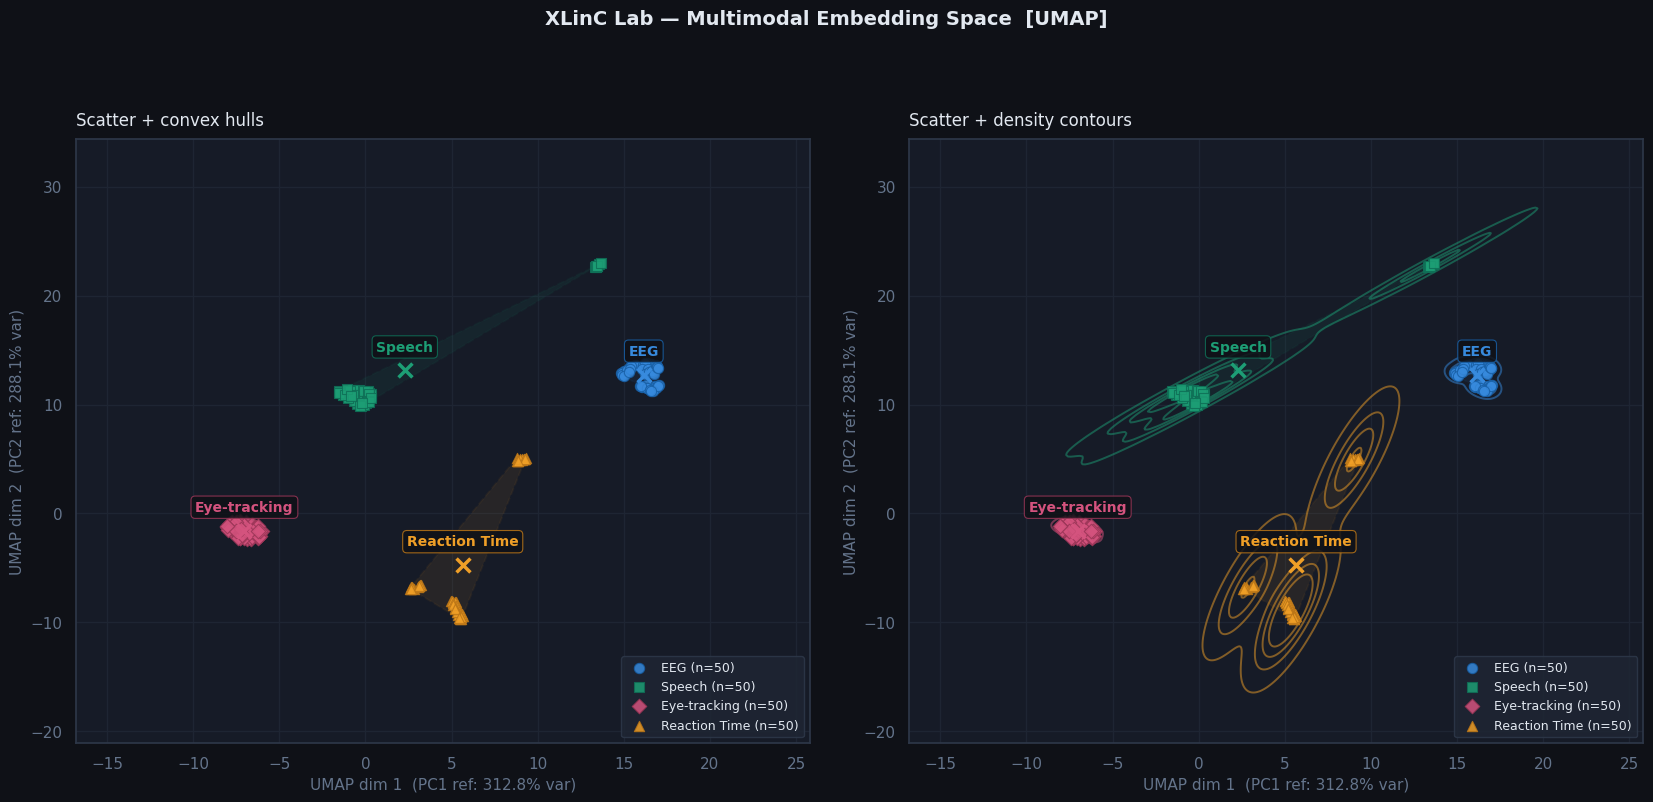

In [20]:
# ══════════════════════════════════════════════════════════════════
# PLOT 2 — Seaborn scatter + density (2 panels)
# ══════════════════════════════════════════════════════════════════

sns.set_theme(style="darkgrid", rc={
    "figure.facecolor": "#0f1117", "axes.facecolor":   "#161b27",
    "grid.color":       "#1e2533", "axes.edgecolor":   "#2d3748",
    "axes.labelcolor":  "#94a3b8", "xtick.color":      "#64748b",
    "ytick.color":      "#64748b", "text.color":       "#e2e8f0",
})

COLORS  = [p["fill"] for p in PALETTE]
EDGES   = [p["line"] for p in PALETTE]
MRKRS   = ["o","s","D","^"]
n_clusters = cluster_labels.max() + 1

# Axis limits with padding
pad   = 0.35
xr    = coords[:,0].max() - coords[:,0].min()
yr    = coords[:,1].max() - coords[:,1].min()
xlim  = (coords[:,0].min()-pad*xr, coords[:,0].max()+pad*xr)
ylim  = (coords[:,1].min()-pad*yr, coords[:,1].max()+pad*yr)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.patch.set_facecolor("#0f1117")
fig.suptitle(f"XLinC Lab — Multimodal Embedding Space  [{method_used}]",
             fontsize=14, color="#e2e8f0", fontweight="bold", y=1.02)

for ax_i, ax in enumerate(axes):
    ax.set_facecolor("#161b27")

    # Convex hulls per modality
    for mid, name in enumerate(mod_names):
        mask = mod_ids == mid
        pts  = coords[mask]
        if len(pts) >= 3:
            try:
                hull  = ConvexHull(pts)
                poly  = pts[hull.vertices]
                ax.add_patch(MplPolygon(
                    poly, closed=True,
                    facecolor=COLORS[mid], edgecolor=EDGES[mid],
                    alpha=0.08, linewidth=1.4, linestyle="--", zorder=1,
                ))
            except Exception:
                pass

    # Scatter
    for mid, name in enumerate(mod_names):
        mask = mod_ids == mid
        ax.scatter(coords[mask,0], coords[mask,1],
                   s=55, c=COLORS[mid], edgecolors=EDGES[mid],
                   linewidths=0.8, marker=MRKRS[mid],
                   label=f"{name} (n={mask.sum()})", zorder=3, alpha=0.85)
        # Centroid label
        cx, cy = coords[mask,0].mean(), coords[mask,1].mean()
        ax.annotate(name, xy=(cx,cy), xytext=(0,14),
                    textcoords="offset points", ha="center",
                    fontsize=10, color=COLORS[mid], fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc="#0f1117",
                              ec=EDGES[mid], lw=0.8, alpha=0.85))
        ax.scatter(cx, cy, s=100, c=COLORS[mid], marker="x",
                   linewidths=2.5, zorder=5, alpha=1.0)

    # Density contours on right panel
    if ax_i == 1:
        for mid, name in enumerate(mod_names):
            mask = mod_ids == mid
            if mask.sum() >= 10:
                try:
                    sns.kdeplot(x=coords[mask,0], y=coords[mask,1],
                                ax=ax, levels=5, color=COLORS[mid],
                                alpha=0.50, linewidths=1.4, fill=False)
                except Exception:
                    pass

    title = "Scatter + convex hulls" if ax_i==0 else "Scatter + density contours"
    ax.set_title(title, fontsize=12, color="#e2e8f0", pad=10, loc="left")
    ax.set_xlabel(f"{method_used} dim 1  (PC1 ref: {var1:.1f}% var)",
                  fontsize=11, color="#64748b")
    ax.set_ylabel(f"{method_used} dim 2  (PC2 ref: {var2:.1f}% var)",
                  fontsize=11, color="#64748b")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.legend(loc="lower right", fontsize=9,
              facecolor="#1e2533", edgecolor="#2d3748",
              labelcolor="#e2e8f0", framealpha=0.9)

plt.tight_layout(pad=2.0)
plt.savefig("xlinc_umap_seaborn.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("✓ Seaborn plot saved → xlinc_umap_seaborn.png")
plt.show()

✓ Similarity heatmap saved → xlinc_similarity_heatmap.png


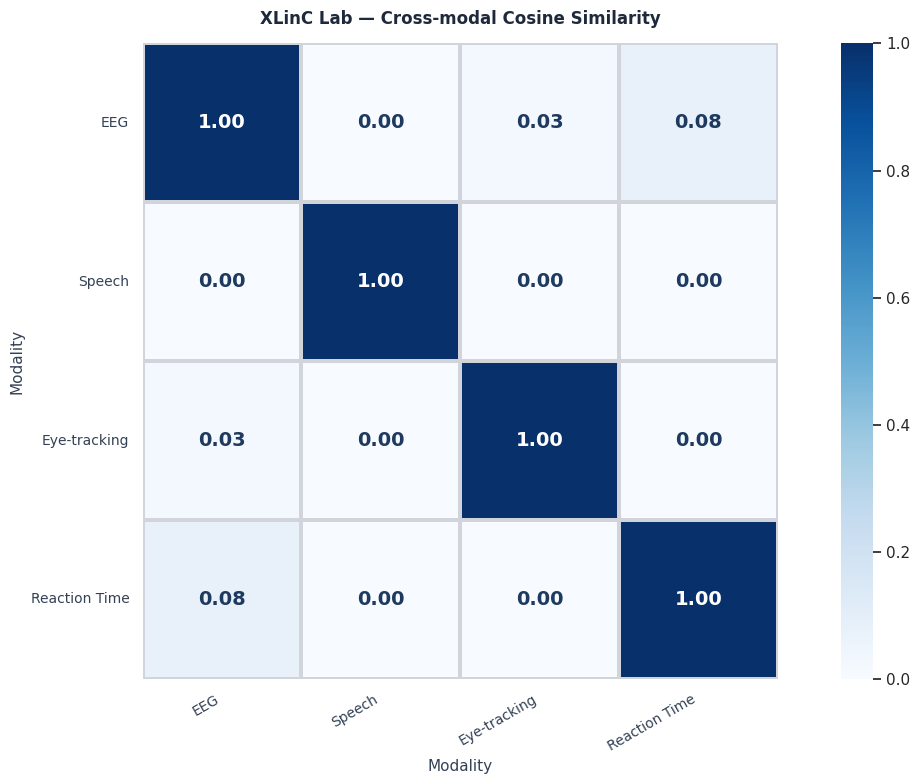


═══════════════════════════════════════════════════════
  ✓ All 5 parts complete!  Files saved:
    eeg_data_overview.png
    speech_sample_overview.png
    eyetracking_overview.png
    rt_data_overview.png
    pca_projection.png
    xlinc_umap_plotly.html
    xlinc_umap_seaborn.png
    xlinc_similarity_heatmap.png
═══════════════════════════════════════════════════════


In [23]:
# ══════════════════════════════════════════════════════════════════
# PLOT 3 — Cross-modal cosine similarity heatmap
# ══════════════════════════════════════════════════════════════════

n  = len(mod_names)
sim = np.zeros((n, n))
for i, ni in enumerate(mod_names):
    for j, nj in enumerate(mod_names):
        if i == j:
            sim[i,j] = 1.0
        else:
            ei = embeddings[ni]
            ej = embeddings[nj]
            ei_n = ei / (np.linalg.norm(ei, axis=1, keepdims=True) + 1e-9)
            ej_n = ej / (np.linalg.norm(ej, axis=1, keepdims=True) + 1e-9)
            sim[i,j] = float(np.clip((ei_n @ ej_n.T).mean(), 0, 1))

annots = np.vectorize(lambda v: f"{v:.2f}")(sim)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor("white")

sns.heatmap(
    sim, annot=annots, fmt="",
    xticklabels=mod_names, yticklabels=mod_names,
    cmap="Blues", vmin=0, vmax=1,
    linewidths=1.5, linecolor="#d1d5db",
    ax=ax, annot_kws={"size": 14, "fontweight": "bold"}, square=True,
)
threshold = 0.6
for idx, t in enumerate(ax.texts):
    i, j = divmod(idx, n)
    t.set_color("white" if sim[i,j] > threshold else "#1e3a5f")

ax.set_title("XLinC Lab — Cross-modal Cosine Similarity",
             fontsize=12, color="#1e293b", pad=14, fontweight="bold")
ax.set_xlabel("Modality", fontsize=11, color="#334155")
ax.set_ylabel("Modality", fontsize=11, color="#334155")
ax.tick_params(colors="#334155", labelsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("xlinc_similarity_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor="white")
print("✓ Similarity heatmap saved → xlinc_similarity_heatmap.png")
plt.show()

print("\n" + "═"*55)
print("  ✓ All 5 parts complete!  Files saved:")
for f in ["eeg_data_overview.png", "speech_sample_overview.png",
          "eyetracking_overview.png", "rt_data_overview.png",
          "pca_projection.png", "xlinc_umap_plotly.html",
          "xlinc_umap_seaborn.png", "xlinc_similarity_heatmap.png"]:
    print(f"    {f}")
print("═"*55)

# t-SNE plot

Running t-SNE (perplexity=20, 1000 iterations) ...
✓ t-SNE complete  |  KL divergence = 0.1068
✓ t-SNE plot saved → xlinc_tsne_seaborn.png


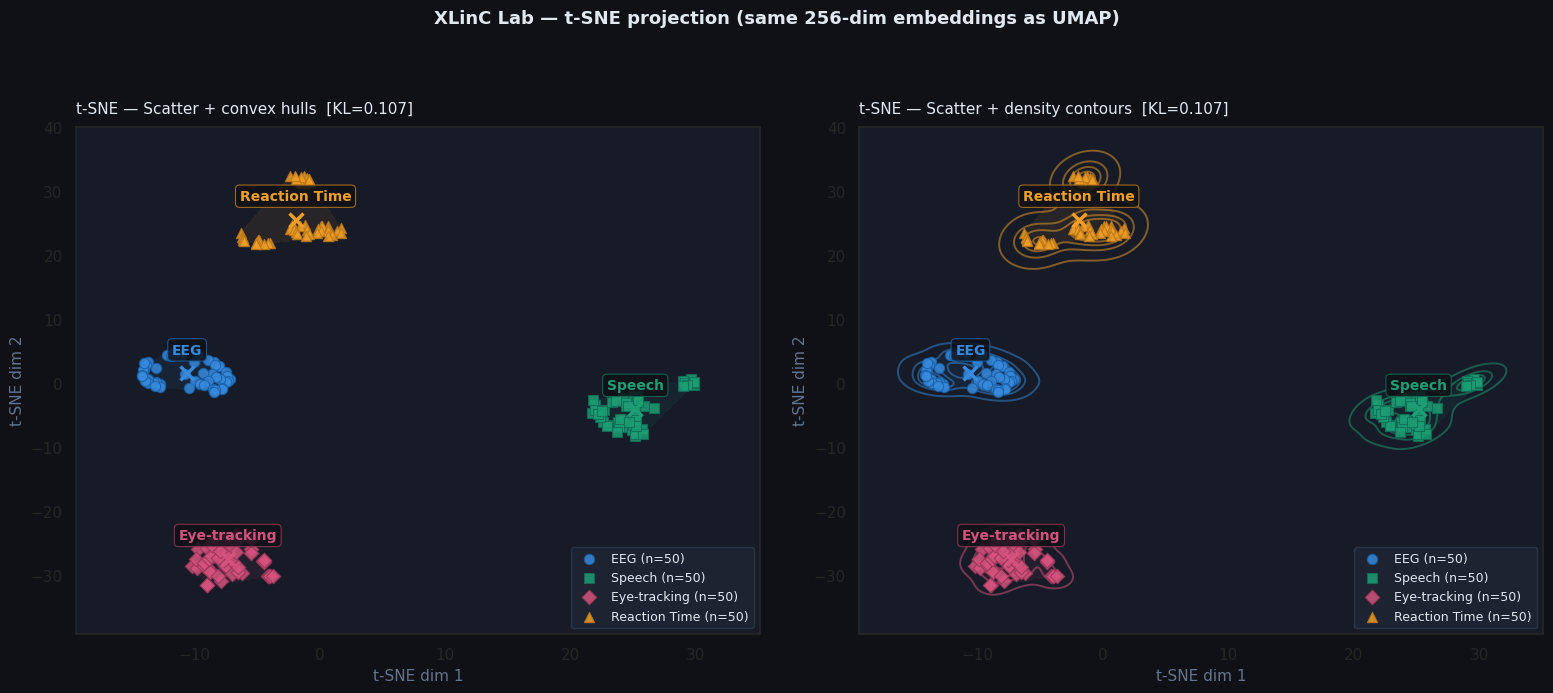

In [22]:
# ── t-SNE projection + plot ──────────────────────────────────────
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from scipy.spatial import ConvexHull

print("Running t-SNE (perplexity=20, 1000 iterations) ...")
tsne        = TSNE(n_components=2, perplexity=20,
                   random_state=SEED, n_iter=1000,
                   learning_rate="auto", init="pca", verbose=0)
coords_tsne = tsne.fit_transform(all_embs).astype("float32")
print(f"✓ t-SNE complete  |  KL divergence = {tsne.kl_divergence_:.4f}")

# ── Plot ──────────────────────────────────────────────────────────
COLORS  = [p["fill"] for p in PALETTE]
EDGES   = [p["line"] for p in PALETTE]
MARKERS = ["o", "s", "D", "^"]

pad  = 0.12
xr   = coords_tsne[:, 0].max() - coords_tsne[:, 0].min()
yr   = coords_tsne[:, 1].max() - coords_tsne[:, 1].min()
xlim = (coords_tsne[:, 0].min() - pad*xr, coords_tsne[:, 0].max() + pad*xr)
ylim = (coords_tsne[:, 1].min() - pad*yr, coords_tsne[:, 1].max() + pad*yr)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("XLinC Lab — t-SNE projection (same 256-dim embeddings as UMAP)",
             fontsize=13, color="#e2e8f0", fontweight="bold", y=1.01)

for ax_i, ax in enumerate(axes):
    ax.set_facecolor("#161b27")

    # Convex hulls per modality
    for mid, name in enumerate(mod_names):
        mask = mod_ids == mid
        pts  = coords_tsne[mask]
        if len(pts) >= 3:
            try:
                hull = ConvexHull(pts)
                ax.add_patch(MplPolygon(
                    pts[hull.vertices], closed=True,
                    facecolor=COLORS[mid], edgecolor=EDGES[mid],
                    alpha=0.08, linewidth=1.4, linestyle="--", zorder=1,
                ))
            except Exception:
                pass

    # Scatter
    for mid, name in enumerate(mod_names):
        mask = mod_ids == mid
        ax.scatter(coords_tsne[mask, 0], coords_tsne[mask, 1],
                   s=55, c=COLORS[mid], edgecolors=EDGES[mid],
                   linewidths=0.8, marker=MARKERS[mid],
                   label=f"{name} (n={mask.sum()})",
                   zorder=3, alpha=0.85)
        cx = coords_tsne[mask, 0].mean()
        cy = coords_tsne[mask, 1].mean()
        ax.annotate(name, xy=(cx, cy), xytext=(0, 14),
                    textcoords="offset points", ha="center",
                    fontsize=10, color=COLORS[mid], fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.3", fc="#0f1117",
                              ec=EDGES[mid], lw=0.8, alpha=0.85))
        ax.scatter(cx, cy, s=100, c=COLORS[mid],
                   marker="x", linewidths=2.5, zorder=5)

    # Density contours on right panel
    if ax_i == 1:
        import seaborn as sns
        for mid in range(len(mod_names)):
            mask = mod_ids == mid
            if mask.sum() >= 10:
                try:
                    sns.kdeplot(x=coords_tsne[mask, 0],
                                y=coords_tsne[mask, 1],
                                ax=ax, levels=5,
                                color=COLORS[mid],
                                alpha=0.5, linewidths=1.4, fill=False)
                except Exception:
                    pass

    title = "Scatter + convex hulls" if ax_i == 0 else "Scatter + density contours"
    ax.set_title(f"t-SNE — {title}  [KL={tsne.kl_divergence_:.3f}]",
                 fontsize=11, color="#e2e8f0", pad=10, loc="left")
    ax.set_xlabel("t-SNE dim 1", fontsize=11, color="#64748b")
    ax.set_ylabel("t-SNE dim 2", fontsize=11, color="#64748b")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.legend(loc="lower right", fontsize=9,
              facecolor="#1e2533", edgecolor="#2d3748",
              labelcolor="#e2e8f0", framealpha=0.9)

plt.tight_layout(pad=2.0)
plt.savefig("xlinc_tsne_seaborn.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print("✓ t-SNE plot saved → xlinc_tsne_seaborn.png")
plt.show()